# 1、ConversationTokenBufferMemory的使用

举例1：

In [1]:

import os
import dotenv
from langchain_openai import ChatOpenAI

dotenv.load_dotenv()

os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY1")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")

# 创建大模型实例
llm = ChatOpenAI(model="qwen2.5-coder:1.5b")

In [2]:
# 1.导入相关包
from langchain.memory import ConversationTokenBufferMemory
from langchain_openai import ChatOpenAI

# 2.创建大模型
llm = ChatOpenAI(model="qwen2.5-coder:1.5b")

# 3.定义ConversationTokenBufferMemory对象
memory = ConversationTokenBufferMemory(
    llm=llm,
    max_token_limit=10  # 设置token上限，默认值为2000
)

# 添加对话
memory.save_context({"input": "你好吗？"}, {"output": "我很好，谢谢！"})
memory.save_context({"input": "今天天气如何？"}, {"output": "晴天，25度"})

# 查看当前记忆
print(memory.load_memory_variables({}))

{'history': "{'input': '你好吗？'}\n{'output': '我很好，谢谢！'}\n{'input': '今天天气如何？'}\n{'output': '晴天，25度'}"}


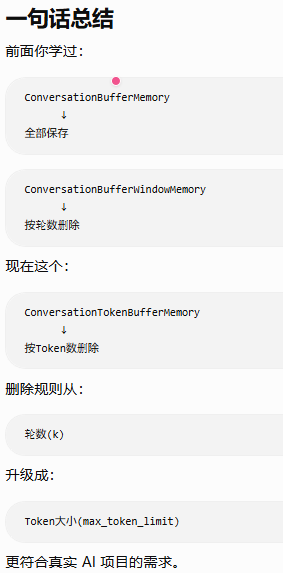

举例2：

In [3]:
# 1.导入相关包
from langchain.memory import ConversationTokenBufferMemory
from langchain_openai import ChatOpenAI

# 2.创建大模型
llm = ChatOpenAI(model="qwen2.5-coder:1.5b")

# 3.定义ConversationTokenBufferMemory对象
memory = ConversationTokenBufferMemory(
    llm=llm,
    max_token_limit=20  # 设置token上限，默认值为2000
)

# 添加对话
memory.save_context({"input": "你好吗？"}, {"output": "我很好，谢谢！"})
memory.save_context({"input": "今天天气如何？"}, {"output": "晴天，25度"})

# 查看当前记忆
print(memory.load_memory_variables({}))

{'history': "{'input': '你好吗？'}\n{'output': '我很好，谢谢！'}\n{'input': '今天天气如何？'}\n{'output': '晴天，25度'}"}


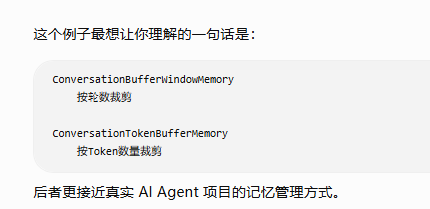

# 2、ConversationSummaryMemory的使用

举例1：

如果实例化ConversationSummaryMemory前，没有历史消息，可以使用构造方法实例化

In [4]:
# 1.导入相关包
from langchain.memory import ConversationSummaryMemory, ChatMessageHistory
from langchain_openai import ChatOpenAI

# 2.创建大模型
llm = ChatOpenAI(model="qwen2.5-coder:1.5b")

# 3.定义ConversationSummaryMemory对象
memory = ConversationSummaryMemory(llm=llm)

# 4.存储消息
memory.save_context({"input": "你好"}, {"output": "怎么了"})
memory.save_context({"input": "你是谁"}, {"output": "我是AI助手小智"})
memory.save_context({"input": "初次对话，你能介绍一下你自己吗？"}, {"output": "当然可以了。我是一个无所不能的小智。"})

# 5.读取消息（总结后的）
print(memory.load_memory_variables({}))

{'history': "{'input': '你好'}\n{'output': '怎么了'}\n{'input': '你是谁'}\n{'output': '我是AI助手小智'}\n{'input': '初次对话，你能介绍一下你自己吗？'}\n{'output': '当然可以了。我是一个无所不能的小智。'}"}


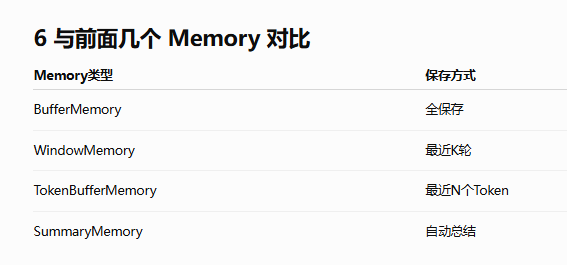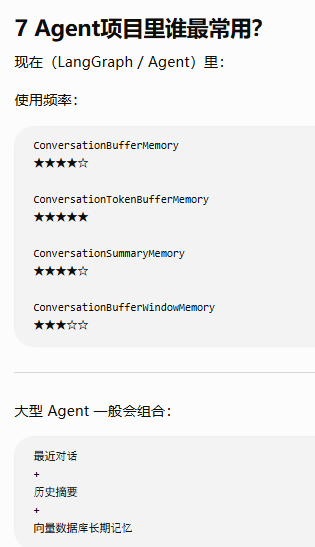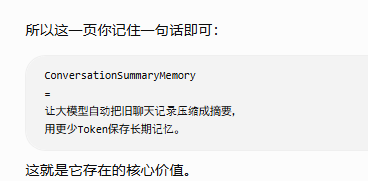

举例2：如果实例化ConversationSummaryMemory前，已经有历史消息，可以调用from_messages()实例化

In [5]:
# 1.导入相关包
from langchain.memory import ConversationSummaryMemory, ChatMessageHistory
from langchain_openai import ChatOpenAI

# 2.定义ChatMessageHistory对象
llm = ChatOpenAI(model="qwen2.5-coder:1.5b")

# 3.假设原始消息
history = ChatMessageHistory()
history.add_user_message("你好，你是谁？")
history.add_ai_message("我是AI助手小智")

# 4.创建ConversationSummaryMemory的实例
memory = ConversationSummaryMemory.from_messages(
    llm = llm,
    #是生成摘要的原材料 保留完整对话供必要时回溯。当新增对话时，LLM需要结合原始历史生成新摘要
    chat_memory = history,
)

print(memory.load_memory_variables({}))


memory.save_context(inputs={"human":"我的名字叫小明"},outputs={"ai":"很高兴认识你"})

print(memory.load_memory_variables({}))

#记录了历史的交互的消息
print(memory.chat_memory.messages)


{'history': '你好，你是谁？\n我是AI助手小智'}
{'history': "你好，你是谁？\n我是AI助手小智\n{'human': '我的名字叫小明'}\n{'ai': '很高兴认识你'}"}
[HumanMessage(content='你好，你是谁？', additional_kwargs={}), AIMessage(content='我是AI助手小智', additional_kwargs={}), HumanMessage(content="{'human': '我的名字叫小明'}", additional_kwargs={}), AIMessage(content="{'ai': '很高兴认识你'}", additional_kwargs={})]


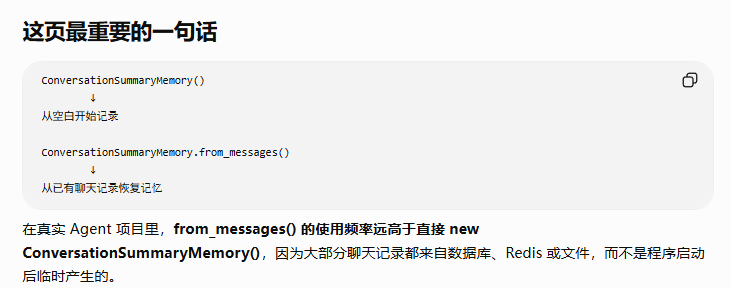

# 3、ConversationSummaryBufferMemory的使用

举例1：

In [6]:
from langchain.memory import ConversationSummaryBufferMemory

# 获取大模型
llm = ChatOpenAI(model="qwen2.5-coder:1.5b")

# 实例化ConversationSummaryBufferMemory
memory = ConversationSummaryBufferMemory(
    llm = llm,
    max_token_limit=40,  #控制缓冲区的大小
    return_messages=True,
)

# 向memory中存储信息
memory.save_context(inputs={"input":"你好，我的名字叫小明"},outputs={"output":"很高兴认识你"})
memory.save_context(inputs={"input":"李白是哪个朝代的诗人"},outputs={"output":"李白是唐朝的诗人"})
memory.save_context(inputs={"input":"唐宋八大家里有苏轼吗？"},outputs={"output":"有"})

print(memory.load_memory_variables({}))

print("\n")

print(memory.chat_memory.messages)

{'history': [HumanMessage(content="{'input': '你好，我的名字叫小明'}", additional_kwargs={}), AIMessage(content="{'output': '很高兴认识你'}", additional_kwargs={}), HumanMessage(content="{'input': '李白是哪个朝代的诗人'}", additional_kwargs={}), AIMessage(content="{'output': '李白是唐朝的诗人'}", additional_kwargs={}), HumanMessage(content="{'input': '唐宋八大家里有苏轼吗？'}", additional_kwargs={}), AIMessage(content="{'output': '有'}", additional_kwargs={})]}


[HumanMessage(content="{'input': '你好，我的名字叫小明'}", additional_kwargs={}), AIMessage(content="{'output': '很高兴认识你'}", additional_kwargs={}), HumanMessage(content="{'input': '李白是哪个朝代的诗人'}", additional_kwargs={}), AIMessage(content="{'output': '李白是唐朝的诗人'}", additional_kwargs={}), HumanMessage(content="{'input': '唐宋八大家里有苏轼吗？'}", additional_kwargs={}), AIMessage(content="{'output': '有'}", additional_kwargs={})]


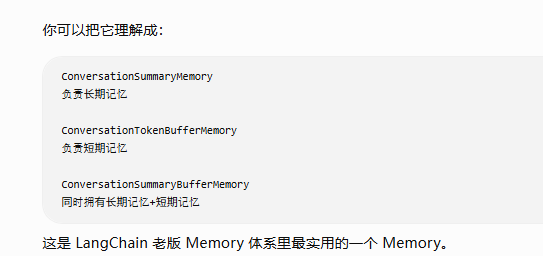

对比组：


In [7]:
from langchain.memory import ConversationSummaryBufferMemory

# 获取大模型
llm = ChatOpenAI(model="qwen2.5-coder:1.5b")

# 实例化ConversationSummaryBufferMemory
memory = ConversationSummaryBufferMemory(
    llm = llm,
    max_token_limit=100,  #控制缓冲区的大小
    return_messages=True,
)

# 向memory中存储信息
memory.save_context(inputs={"input":"你好，我的名字叫小明"},outputs={"output":"很高兴认识你"})
memory.save_context(inputs={"input":"李白是哪个朝代的诗人"},outputs={"output":"李白是唐朝的诗人"})
memory.save_context(inputs={"input":"唐宋八大家里有苏轼吗？"},outputs={"output":"有"})

print(memory.load_memory_variables({}))

print("\n")

print(memory.chat_memory.messages)

{'history': [HumanMessage(content="{'input': '你好，我的名字叫小明'}", additional_kwargs={}), AIMessage(content="{'output': '很高兴认识你'}", additional_kwargs={}), HumanMessage(content="{'input': '李白是哪个朝代的诗人'}", additional_kwargs={}), AIMessage(content="{'output': '李白是唐朝的诗人'}", additional_kwargs={}), HumanMessage(content="{'input': '唐宋八大家里有苏轼吗？'}", additional_kwargs={}), AIMessage(content="{'output': '有'}", additional_kwargs={})]}


[HumanMessage(content="{'input': '你好，我的名字叫小明'}", additional_kwargs={}), AIMessage(content="{'output': '很高兴认识你'}", additional_kwargs={}), HumanMessage(content="{'input': '李白是哪个朝代的诗人'}", additional_kwargs={}), AIMessage(content="{'output': '李白是唐朝的诗人'}", additional_kwargs={}), HumanMessage(content="{'input': '唐宋八大家里有苏轼吗？'}", additional_kwargs={}), AIMessage(content="{'output': '有'}", additional_kwargs={})]


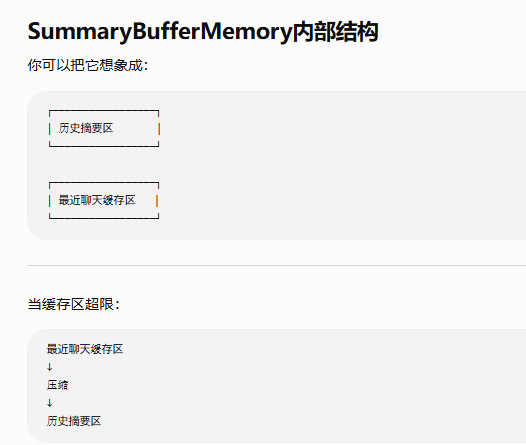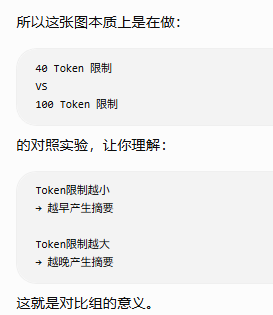

举例2：模拟客服交互

In [8]:
from langchain.memory import ConversationSummaryBufferMemory
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain.chains.llm import LLMChain

# 1、初始化大语言模型
llm = ChatOpenAI(
    model="qwen2.5-coder:1.5b",
    temperature=0.5,
    max_tokens=500
)

# 2、定义提示模板
prompt = ChatPromptTemplate.from_messages([
    ("system", "你是电商客服助手，用中文友好回复用户问题。保持专业但亲切的语气。"),
    MessagesPlaceholder(variable_name="chat_history"),
    ("human", "{input}")
])


# 3、创建带摘要缓冲的记忆系统
memory = ConversationSummaryBufferMemory(
    llm=llm,
    max_token_limit=400,
    memory_key="chat_history",
    return_messages=True
)

# 4、创建对话链
chain = LLMChain(
    llm=llm,
    prompt=prompt,
    memory=memory,
)

# 5、模拟多轮对话
dialogue = [
    ("你好，我想查询订单12345的状态", None),
    ("这个订单是上周五下的", None),
    ("我现在急着用，能加急处理吗", None),
    ("等等，我可能记错订单号了，应该是12346", None),
    ("对了，你们退货政策是怎样的", None)
]

# 6、执行对话
for user_input, _ in dialogue:
    response = chain.invoke({"input": user_input})
    print(f"用户: {user_input}")
    print(f"客服: {response['text']}\n")

# 7、查看当前记忆状态
print("\n=== 当前记忆内容 ===")
print(memory.load_memory_variables({}))

用户: 你好，我想查询订单12345的状态
客服: 你好！很高兴能够帮助你的订单状态查询。请告诉我具体的订单编号“12345”，以便我可以进行查询。如果你需要查询更多关于订单的状态信息，比如订单信息、物流状态等，也可以告诉我，我将尽力提供帮助。

用户: 这个订单是上周五下的
客服: {'output': '好的，请稍后给我确认订单编号“12345”的确认信息。“确认信息”是订单下注时间、支付方式、收货方信息、物流信息等全部的详细信息。请确认你是否阅读了确认信息并已经确认了订单的相关信息吗？如果你需要提供更多关于这个订单的状态查询信息，可以随时告知我。'}

用户: 我现在急着用，能加急处理吗
客服: {'output': "{'output': '当然可以，您的请求已即时接收，并且我会尽快为您处理相关订单状态。请您放心，您的订单一定会尽快得到解决。'}"}

用户: 等等，我可能记错订单号了，应该是12346
客服: {'output': "{\"output\": \"好的，非常抱歉让您误解。请提供您提到的订单编号“12346”，我会尽快为您确认订单的信息。如果您需要了解订单的其他状态信息，也可以随时告诉我。\"}"}

用户: 对了，你们退货政策是怎样的
客服: {'output': '{\'output\': \'{\'output\': \\"您的订单退款政策可能会有所不同，建议您直接联系我们客服（通常是客服邮箱：example@example.com 或网站客服热线）获取确认信息。如果您需要了解有关订单退款和更换政策的详细内容，我可以提供给您更多的帮助和建议。\'\"}'}'}


=== 当前记忆内容 ===
{'chat_history': [HumanMessage(content="{'input': '你好，我想查询订单12345的状态'}", additional_kwargs={}), AIMessage(content="{'output': '你好！很高兴能够帮助你的订单状态查询。请告诉我具体的订单编号“12345”，以便我可以进行查询。如果你需要查询更多关于订单的状态信息，比如订单信息、物流状态等，也可以告诉我，我将尽力提供帮助。'}", additional_kwargs={}), HumanMessage(content="{'i

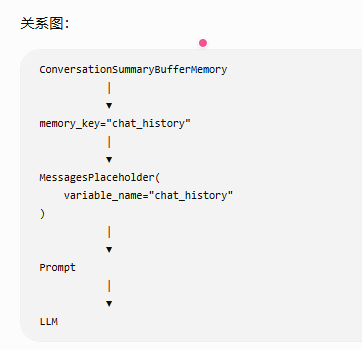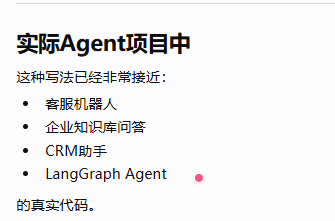

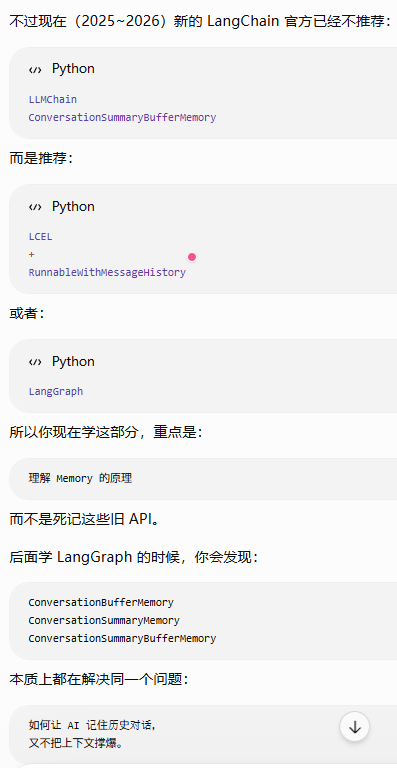

# 4、ConversationEntityMemory的使用（了解）

In [9]:
from langchain.chains.conversation.base import LLMChain
from langchain.memory import ConversationEntityMemory
from langchain.memory.prompt import ENTITY_MEMORY_CONVERSATION_TEMPLATE
from langchain_openai import ChatOpenAI

# 初始化大语言模型
llm = ChatOpenAI(model_name='qwen2.5-coder:1.5b', temperature=0)
# 使用LangChain为实体记忆设计的预定义模板
prompt = ENTITY_MEMORY_CONVERSATION_TEMPLATE
# 初始化实体记忆
memory = ConversationEntityMemory(llm=llm)
# 提供对话链
chain = LLMChain(
    llm=llm,
    prompt=ENTITY_MEMORY_CONVERSATION_TEMPLATE,
    memory=ConversationEntityMemory(llm=llm),
    #verbose=True,  # 设置为True可以看到链的详细推理过程
)

# 进行几轮对话，记忆组件会在后台自动提取和存储实体信息
chain.invoke(input="你好，我叫蜘蛛侠。我的好朋友包括钢铁侠、美国队长和绿巨人。")
chain.invoke(input="我住在纽约。")
chain.invoke(input="我使用的装备是由斯塔克工业提供的。")

# 查询记忆体中存储的实体信息
print("\n当前存储的实体信息:")
print(chain.memory.entity_store.store)




当前存储的实体信息:
{'钢铁侠': '你好，我叫蜘蛛侠。我的好朋友包括钢铁侠、美国队长和绿巨人。', '美国队长': '你好，我叫蜘蛛侠。我的好朋友包括钢铁侠、美国队长和绿巨人。', '绿巨人': '你好，我叫蜘蛛侠。我的好朋友包括钢铁侠、美国队长和绿巨人。', '蜘蛛侠': '你好，我叫蜘蛛侠。我的好朋友包括钢铁侠、美国队长和绿巨人。', '纽约': '我住在纽约。'}


In [11]:
# 基于记忆进行提问
answer = chain.invoke(input="你能告诉我蜘蛛侠住在哪里以及他的好朋友有哪些吗？")
print("\nAI的回答:")
print(answer)


AI的回答:
{'text': '蜘蛛侠是美国漫威漫画的超级英雄，拥有超人一般的特性和技能。他的朋友们包括钢铁侠、美国队长和绿巨人，他们在 superhero电影的背景中经常搭档作战并对峙。', 'output': '蜘蛛侠是美国漫威漫画的超级英雄，拥有超人一般的特性和技能。他的朋友们包括钢铁侠、美国队长和绿巨人，他们在 superhero电影的背景中经常搭档作战并对峙。'}


# 5、ConversationKGMemory的使用（了解）


In [12]:
#1.导入相关包
from langchain.memory import ConversationKGMemory
from langchain.chat_models import ChatOpenAI

# 2.定义LLM
llm = ChatOpenAI(model="qwen2.5-coder:1.5b", temperature=0)

# 3.定义ConversationKGMemory对象
memory = ConversationKGMemory(llm=llm)

# 4.保存会话
memory.save_context({"input": "向山姆问好"}, {"output": "山姆是谁"})
memory.save_context({"input": "山姆是我的朋友"}, {"output": "好的"})

# 5.查询会话
memory.load_memory_variables({"input": "山姆是谁"})

{'history': "{'input': '向山姆问好'}\n{'output': '山姆是谁'}\n{'input': '山姆是我的朋友'}\n{'output': '好的'}"}

In [13]:
memory.get_knowledge_triplets("她最喜欢的颜色是红色")

[("{'input': '山姆", '是', "我的朋友'}")]

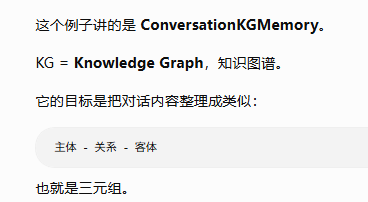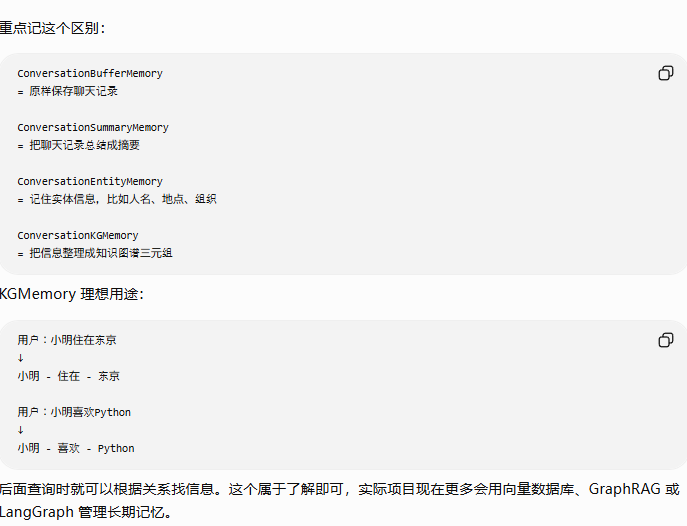

# 6、VectorStoreRetrieverMemory的使用（了解）



In [20]:
# 1.导入相关包
from langchain_ollama import OllamaEmbeddings
from langchain.memory import VectorStoreRetrieverMemory
from langchain_community.vectorstores import FAISS
from langchain.memory import ConversationBufferMemory

# 2.定义ConversationBufferMemory对象
memory = ConversationBufferMemory()
memory.save_context({"input": "我最喜欢的食物是披萨"}, {"output": "很高兴知道"})
memory.save_context({"Human": "我喜欢的运动是跑步"}, {"AI": "好的,我知道了"})
memory.save_context({"Human": "我最喜欢的运动是足球"}, {"AI": "好的,我知道了"})

# 3.定义向量嵌入模型
embeddings_model = OllamaEmbeddings(
    model="nomic-embed-text"
)

# 4.初始化向量数据库
vectorstore = FAISS.from_texts(memory.buffer.split("\n"), embeddings_model)  # 空初始化

# 5.定义检索对象
retriever = vectorstore.as_retriever(search_kwargs=dict(k=1))

# 6.初始化VectorStoreRetrieverMemory
memory = VectorStoreRetrieverMemory(retriever=retriever)

print(memory.load_memory_variables({"prompt": "我最喜欢的食物是"}))

{'history': ''}


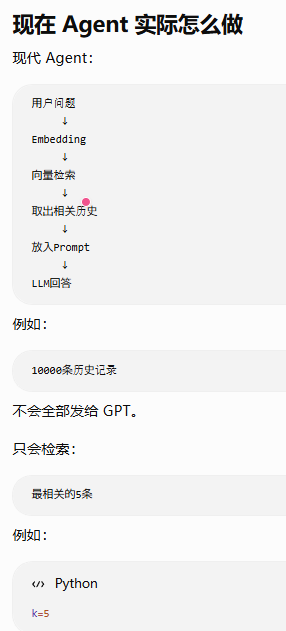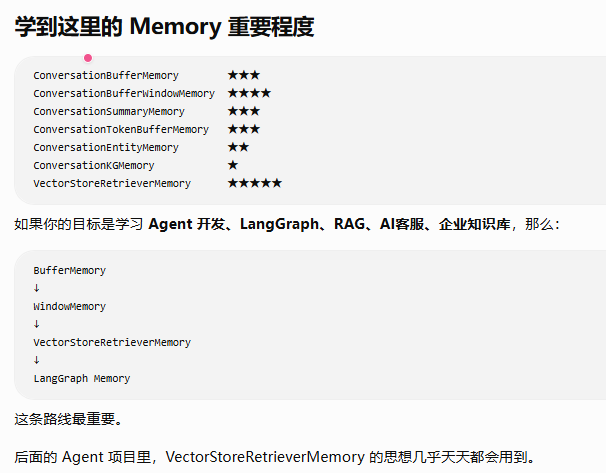